In [56]:
import os
from pathlib import Path

import dotenv
import matplotlib.pyplot as plt
import pyam
import pandas as pd

dotenv.load_dotenv()

# Set up output folder
OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

## Configuration

In [ ]:
# Scenario to plot
ILLUSTRATIVE_SCENARIO = ("IMAGE 3.0.1", "SSP1-19")
#ILLUSTRATIVE_SCENARIO = ("REMIND-MAgPIE 3.3-4.8", "NGFS Phase 5-Low Demand")
#ILLUSTRATIVE_SCENARIO = ("IMAGE 3.2", "SSP2021-SSP1-SPA1-26-Renewables")

# File paths
# NOTE: 100_prepare_sci_data.ipynb now does selection + harmonization + infilling in a
# single step (the SCI v1.1 release is already centrally harmonized/infilled), so there
# is no longer a separate pre-harmonization intermediate file - both paths below point
# to the same file.
INPUT_DATA_FILE = OUTPUT_FOLDER / "100_harmonised_infilled_data.csv"
HARMONISED_DATA_FILE = OUTPUT_FOLDER / "100_harmonised_infilled_data.csv"
NETZERO_CO2_FILE = OUTPUT_FOLDER / "101_netzero_co2_extended.csv"
NETZERO_KYOTO_FILE = OUTPUT_FOLDER / "101_netzero_kyoto_extended.csv"
HISTORY_DATA_FILE = Path(os.environ["HIST_DATA"])

# Year range for historical data
YEAR_RANGE = range(2000, 2101)

## Load Data

In [72]:
model, scenario = ILLUSTRATIVE_SCENARIO

# Input data (original scenario submissions)
input_data = pyam.IamDataFrame(INPUT_DATA_FILE).filter(model=model, scenario=scenario)

# Historical data
history = pyam.IamDataFrame(HISTORY_DATA_FILE)
history_data = pyam.IamDataFrame(
    history.timeseries().reset_index().assign(model="hist")
).filter(year=YEAR_RANGE)

# Harmonised and infilled data
harmonised_data = pyam.IamDataFrame(HARMONISED_DATA_FILE).filter(model=model, scenario=scenario)

# Net-zero extended scenarios
netzero_co2_data = pyam.IamDataFrame(NETZERO_CO2_FILE).filter(
    model=model, scenario=f"{scenario}_NZCO2"
)
netzero_kyoto_data = pyam.IamDataFrame(NETZERO_KYOTO_FILE).filter(
    model=model, scenario=f"{scenario}_NZKyoto"
)

[INFO] 16:01:57 - pyam.core: Reading file /Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_gaurav/output/100_inputdata_20260513.csv
[INFO] 16:01:57 - pyam.core: Reading file /Users/hoegner/Projects/data/historical/cmip7-hist/processed/global-workflow-history_202511261223_202511040855_202512032146_202512021030_7e32405ade790677a6022ff498395bff00d9792d_202511040855_202512071232_202511040855_202511040855_0002_0002.csv
[INFO] 16:01:57 - pyam.core: Reading file /Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_gaurav/output/101_harmonised_data.csv
[INFO] 16:01:59 - pyam.core: Reading file /Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_gaurav/output/102_netzero_co2_extended.csv
[INFO] 16:02:00 - pyam.core: Reading file /Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_gaurav/output/102_netzero_kyoto_extended.csv


## Process CO2 Emissions

In [73]:
# Input data uses different variable naming convention
input_co2 = input_data.add(
    a="Emissions|CO2|Energy and Industrial Processes",
    b="Emissions|CO2|AFOLU",
    name="Emissions|CO2",
)

history_co2 = history_data.add(
    a="Emissions|CO2|Energy and Industrial Processes",
    b="Emissions|CO2|AFOLU",
    name="Emissions|CO2",
)

# Harmonised data uses Fossil/Biosphere naming
harmonised_co2 = harmonised_data.add(
    a="Emissions|CO2|Fossil",
    b="Emissions|CO2|Biosphere",
    name="Emissions|CO2",
)

netzero_co2 = netzero_co2_data.add(
    a="Emissions|CO2|Fossil",
    b="Emissions|CO2|Biosphere",
    name="Emissions|CO2",
)

netzero_kyoto_co2 = netzero_kyoto_data.add(
    a="Emissions|CO2|Fossil",
    b="Emissions|CO2|Biosphere",
    name="Emissions|CO2",
)

## Process CH4 Emissions

In [74]:
CH4_VAR = "Emissions|CH4"

input_ch4 = input_data.filter(variable=CH4_VAR)
history_ch4 = history_data.filter(variable=CH4_VAR)
harmonised_ch4 = harmonised_data.filter(variable=CH4_VAR)
netzero_co2_ch4 = netzero_co2_data.filter(variable=CH4_VAR)
netzero_kyoto_ch4 = netzero_kyoto_data.filter(variable=CH4_VAR)

## Plot

Saved to /Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_gaurav/output/900_illustrative_plot_IMAGE_301_SSP1_19.png


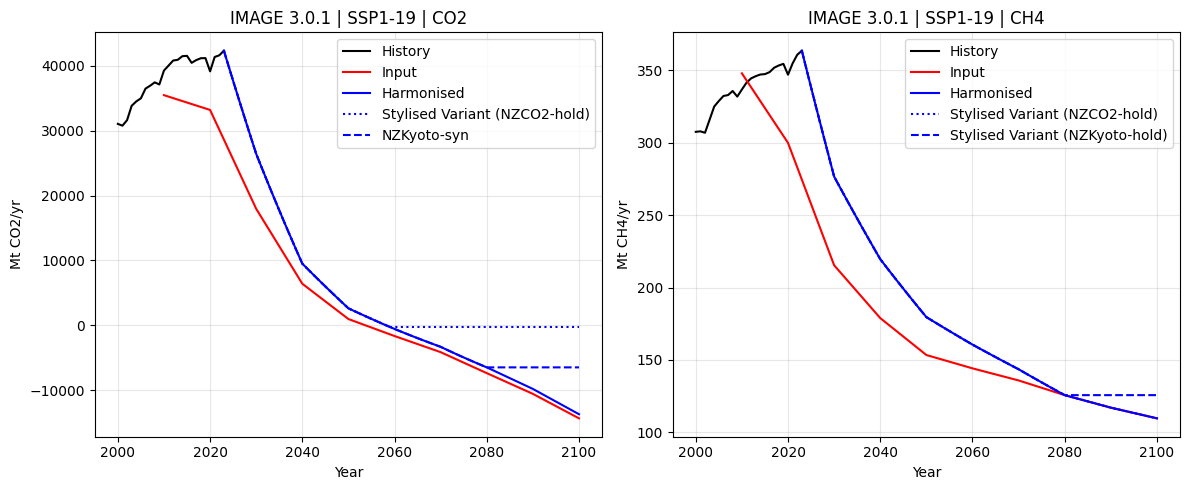

In [177]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CO2 plot
ax = axes[0]
history_co2.plot(ax=ax, color="black", label="History")
input_co2.plot(ax=ax, color="red", label="Input")
harmonised_co2.plot(ax=ax, color="blue", label="Harmonised")
netzero_co2.plot(ax=ax, color="blue", linestyle="dotted", label="Stylised Variant (NZCO2-hold)")
netzero_kyoto_co2.plot(ax=ax, color="blue", linestyle="dashed", label="NZKyoto-syn")
ax.set_title(f"{model} | {scenario} | CO2")
ax.grid(alpha=0.3)

# CH4 plot
ax = axes[1]
history_ch4.plot(ax=ax, color="black", label="History")
input_ch4.plot(ax=ax, color="red", label="Input")
harmonised_ch4.plot(ax=ax, color="blue", label="Harmonised")
netzero_co2_ch4.plot(ax=ax, color="blue", linestyle="dotted", label="Stylised Variant (NZCO2-hold)")
netzero_kyoto_ch4.plot(ax=ax, color="blue", linestyle="dashed", label="Stylised Variant (NZKyoto-hold)")
ax.set_title(f"{model} | {scenario} | CH4")
ax.grid(alpha=0.3)

plt.tight_layout()

# Save figure
output_filename = OUTPUT_FOLDER / f"900_illustrative_plot_{model.replace(' ', '_').replace('.', '')}_{scenario.replace('-', '_')}.png"
fig.savefig(output_filename, dpi=150, bbox_inches="tight")
print(f"Saved to {output_filename}")

In [62]:
harmonised_co2

<class 'pyam.core.IamDataFrame'>
Index:
 * model    : IMAGE 3.2 (1)
 * scenario : SSP2021-SSP1-SPA1-26-Renewables (1)
Timeseries data coordinates:
   region   : World (1)
   variable : Emissions|CO2 (1)
   unit     : Mt CO2/yr (1)
   year     : 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, ... 2100 (78)

## plot MAGICC outcomes for the same scenarios

In [ ]:
# Configuration
INDIVIDUAL_RUNS_DIR = OUTPUT_FOLDER / "individual_runs"
MANIFEST_FILE = OUTPUT_FOLDER / "individual_runs/manifests/regenerated_manifest.csv"

# Load manifest and create lookup dict
manifest = pd.read_csv(MANIFEST_FILE)
manifest["key"] = manifest["model"] + "|" + manifest["scenario"] + "|" + manifest["magicc_flag"]
file_lookup = manifest.set_index("key")["output_filename"].to_dict()

# Get all scenarios with MAGICC_FLAG="ANTHROPOGENIC" as reference scenarios
all_scenarios = manifest[manifest["magicc_flag"] == "ANTHROPOGENIC"][["model", "scenario"]].drop_duplicates()
print(f"Total reference scenarios (MAGICC_FLAG=ANTHROPOGENIC): {len(all_scenarios)}")

In [77]:
filenames = manifest[(manifest["model"]==ILLUSTRATIVE_SCENARIO[0]) & (manifest["scenario"].str.startswith(ILLUSTRATIVE_SCENARIO[1]))]["output_filename"]

In [78]:
filenames

173             IMAGE__3.0.1_SSP1-19_ALL.csv
857             IMAGE__3.0.1_SSP1-19_CO2.csv
1539            IMAGE__3.0.1_SSP1-19_GHG.csv
2226      IMAGE__3.0.1_SSP1-19_NZCO2_CO2.csv
2905      IMAGE__3.0.1_SSP1-19_NZCO2_ALL.csv
3592      IMAGE__3.0.1_SSP1-19_NZCO2_GHG.csv
4170    IMAGE__3.0.1_SSP1-19_NZKyoto_ALL.csv
4501    IMAGE__3.0.1_SSP1-19_NZKyoto_GHG.csv
4828    IMAGE__3.0.1_SSP1-19_NZKyoto_CO2.csv
Name: output_filename, dtype: object

In [79]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.concat(
    [
        pd.read_csv(Path(INDIVIDUAL_RUNS_DIR) / fname).assign(
            run_mode=Path(fname).stem.split("_")[-1]
        )
        for fname in filenames
    ],
    ignore_index=True
)

In [80]:
id_vars = ["climate_model", "model", "region", "run_id", "scenario", "unit", "variable", "run_mode"]
df_sample = df.set_index(id_vars)

In [81]:
df_long = df_sample.reset_index().melt(
    id_vars=id_vars,
    var_name="year",
    value_name="value"
)

df_long["year"] = df_long["year"].astype(int)

In [ ]:
to_plot_subset = df_long[df_long["scenario"]!='SSP1-19_NZKyoto']
to_plot = to_plot_subset[
   # (to_plot_subset["scenario"] != "SSP1-19_NZCO2") |
    (to_plot_subset["run_mode"].isin(["ANTHROPOGENIC", "CO2"]))
]
to_plot2 = to_plot_subset[
    (to_plot_subset["scenario"] != "SSP1-19_NZCO2") &
    (to_plot_subset["run_mode"].isin(["ANTHROPOGENIC", "GHG"]))
]
to_plot3 = to_plot_subset[
    (to_plot_subset["scenario"] != "SSP1-19_NZCO2") &
    (to_plot_subset["run_mode"].isin(["GHG", "CO2"]))
]

In [ ]:
plt.figure(figsize=(6, 4))

to_plot_filtered = to_plot[to_plot["year"]>1999]
to_plot_filtered = to_plot_filtered[to_plot_filtered["run_id"]==62]

style_dict = {
    "ANTHROPOGENIC": (1, 0),      # solid
    "GHG": (5, 2),      # dashed
    "CO2": (1, 2),      # dotted
}

sns.lineplot(
    data=to_plot_filtered,
    x="year",
    y="value",
    units="run_id",
    estimator=None,
    hue="scenario",
    style="run_mode",
    dashes=style_dict,
    legend=True,
    linewidth=2,
    alpha=1
)
plt.legend(loc="upper left")
plt.ylabel("GSAT (°C)")
plt.xlabel("Year")
plt.ylim(0.55,1.5)
plt.grid(alpha=.3)

plt.tight_layout()
output_filename = OUTPUT_FOLDER / f"900_illustrative_plot_GSAT_{model.replace(' ', '_').replace('.', '')}_{scenario.replace('-', '_')}.png"
plt.savefig(output_filename, dpi=150, bbox_inches="tight")
print(f"Saved to {output_filename}")

plt.show()

In [ ]:
plt.figure(figsize=(6, 4))

to_plot_filtered = to_plot2[to_plot2["year"]>1999]
to_plot_filtered = to_plot_filtered[to_plot_filtered["run_id"]==62]

style_dict = {
    "ANTHROPOGENIC": (1, 0),      # solid
    "GHG": (5, 2),      # dashed
    "CO2": (1, 2),      # dotted
}

sns.lineplot(
    data=to_plot_filtered,
    x="year",
    y="value",
    units="run_id",
    estimator=None,
    hue="scenario",
    style="run_mode",
    dashes=style_dict,
    legend=True,
    linewidth=2,
    alpha=1
)

plt.legend(loc="upper left")
plt.ylabel("GSAT (°C)")
plt.xlabel("Year")
plt.grid(alpha=.3)
plt.ylim(0.55,1.5)
plt.tight_layout()
output_filename = OUTPUT_FOLDER / f"900_illustrative_plot_GSAT_Residual_{model.replace(' ', '_').replace('.', '')}_{scenario.replace('-', '_')}.png"
plt.savefig(output_filename, dpi=150, bbox_inches="tight")
print(f"Saved to {output_filename}")

plt.show()

In [ ]:
plt.figure(figsize=(6, 4))

to_plot_filtered = to_plot3[to_plot3["year"]>1999]
to_plot_filtered = to_plot_filtered[to_plot_filtered["run_id"]==62]

style_dict = {
    "ANTHROPOGENIC": (1, 0),      # solid
    "GHG": (5, 2),      # dashed
    "CO2": (1, 2),      # dotted
}

sns.lineplot(
    data=to_plot_filtered,
    x="year",
    y="value",
    units="run_id",
    estimator=None,
    hue="scenario",
    style="run_mode",
    dashes=style_dict,
    legend=True,
    linewidth=2,
    alpha=1
)

plt.legend(loc="upper left")
plt.ylabel("GSAT (°C)")
plt.xlabel("Year")
plt.grid(alpha=.3)
plt.ylim(0.55,1.5)
plt.tight_layout()
output_filename = OUTPUT_FOLDER / f"900_illustrative_plot_GSAT_GHGs_{model.replace(' ', '_').replace('.', '')}_{scenario.replace('-', '_')}.png"
plt.savefig(output_filename, dpi=150, bbox_inches="tight")
print(f"Saved to {output_filename}")

plt.show()

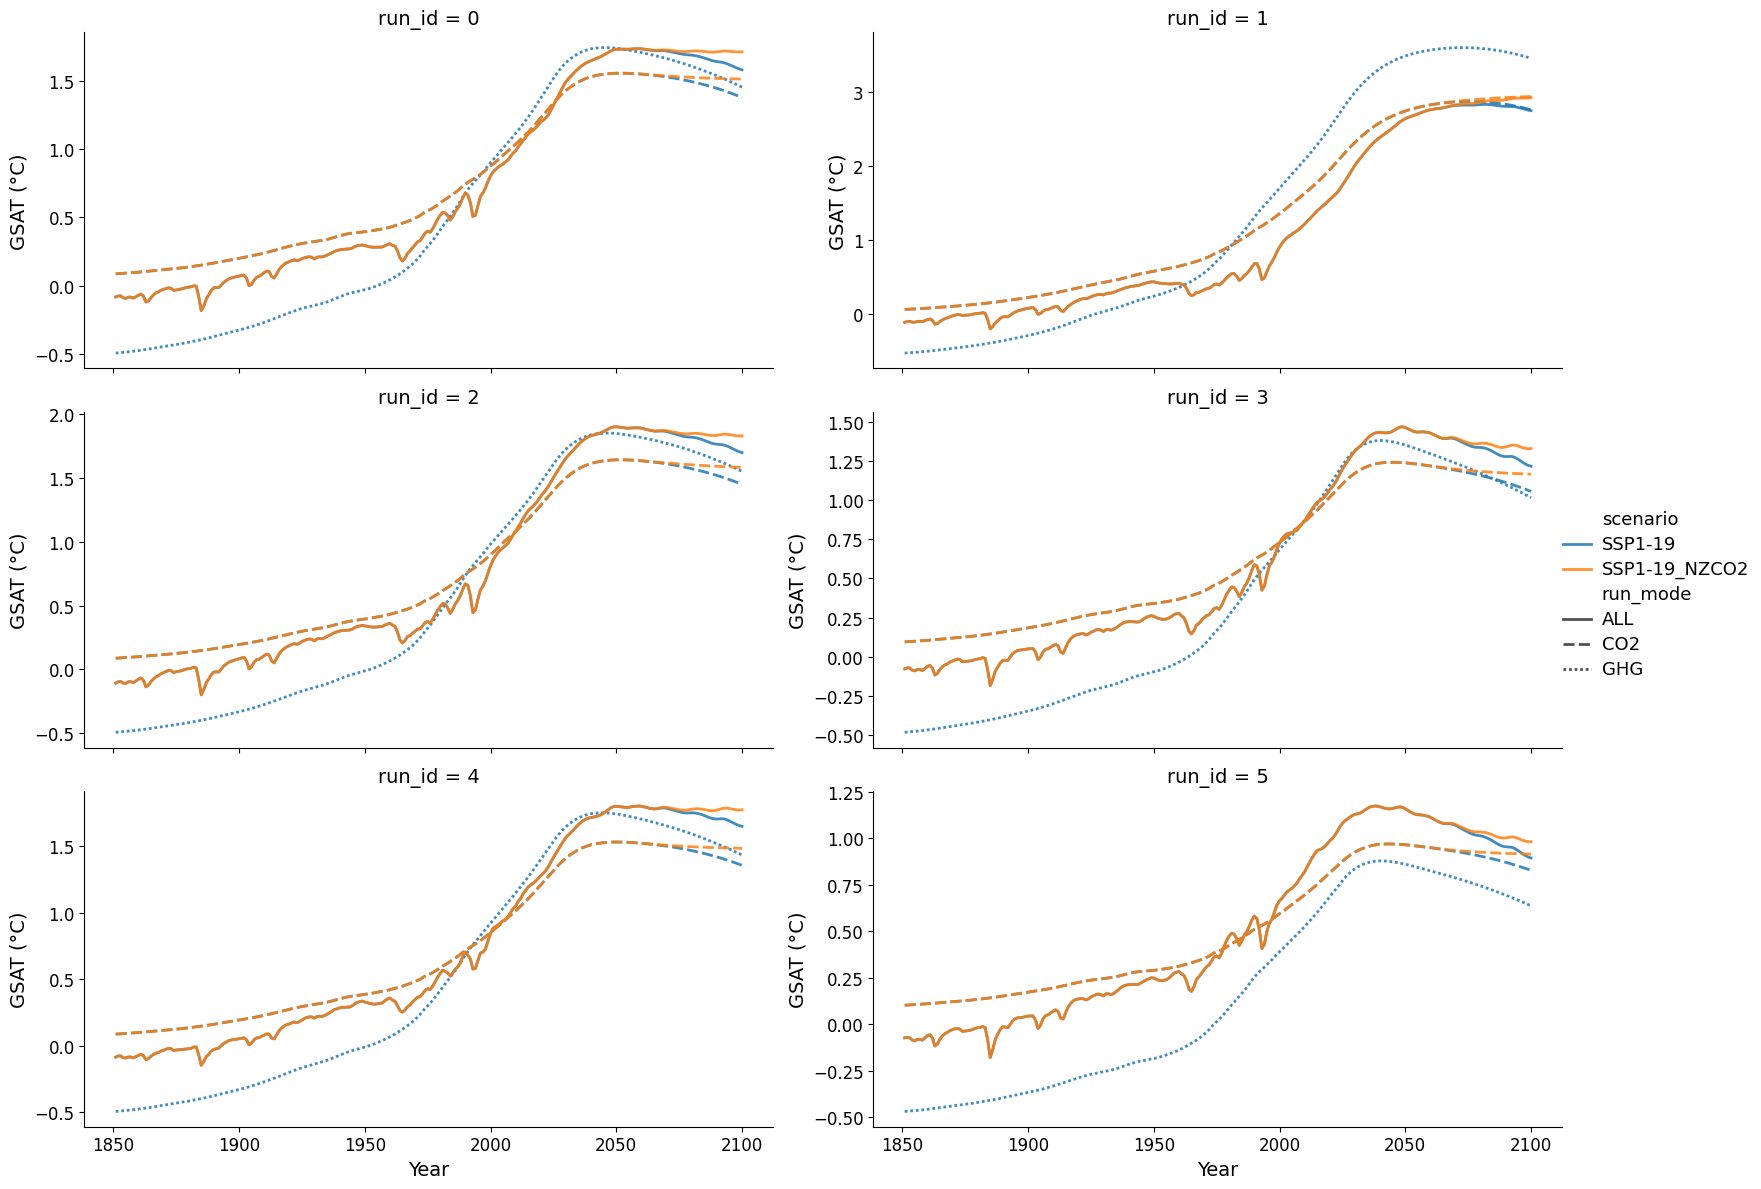

In [194]:
to_plot_filtered = to_plot[to_plot["year"]>1850]
to_plot_filtered = to_plot_filtered[to_plot_filtered["run_id"]<6]


g = sns.relplot(
    data=to_plot_filtered,
    x="year",
    y="value",
    kind="line",
    col="run_id",      # 👈 key: keeps each ensemble member separate
    estimator=None,      # 👈 disables aggregation (important!)
    hue="scenario",      # or run_id if you prefer full ensemble coloring
    style="run_mode",
    col_wrap=2,
    height=4,
    aspect=2,
    facet_kws={"sharey": False},
    linewidth=2,
    alpha=0.85,          # 👈 makes ensemble structure visible
)

for ax in g.axes.flat:
    ax.set_xlabel("Year", fontsize=14)
    ax.set_ylabel("GSAT (°C)", fontsize=14)

    ax.tick_params(axis="both", labelsize=12)

    ax.title.set_fontsize(14)

g.legend.get_title().set_fontsize(15)

for t in g.legend.get_texts():
    t.set_fontsize(13)
    
g.tight_layout();

<Figure size 800x1200 with 0 Axes>

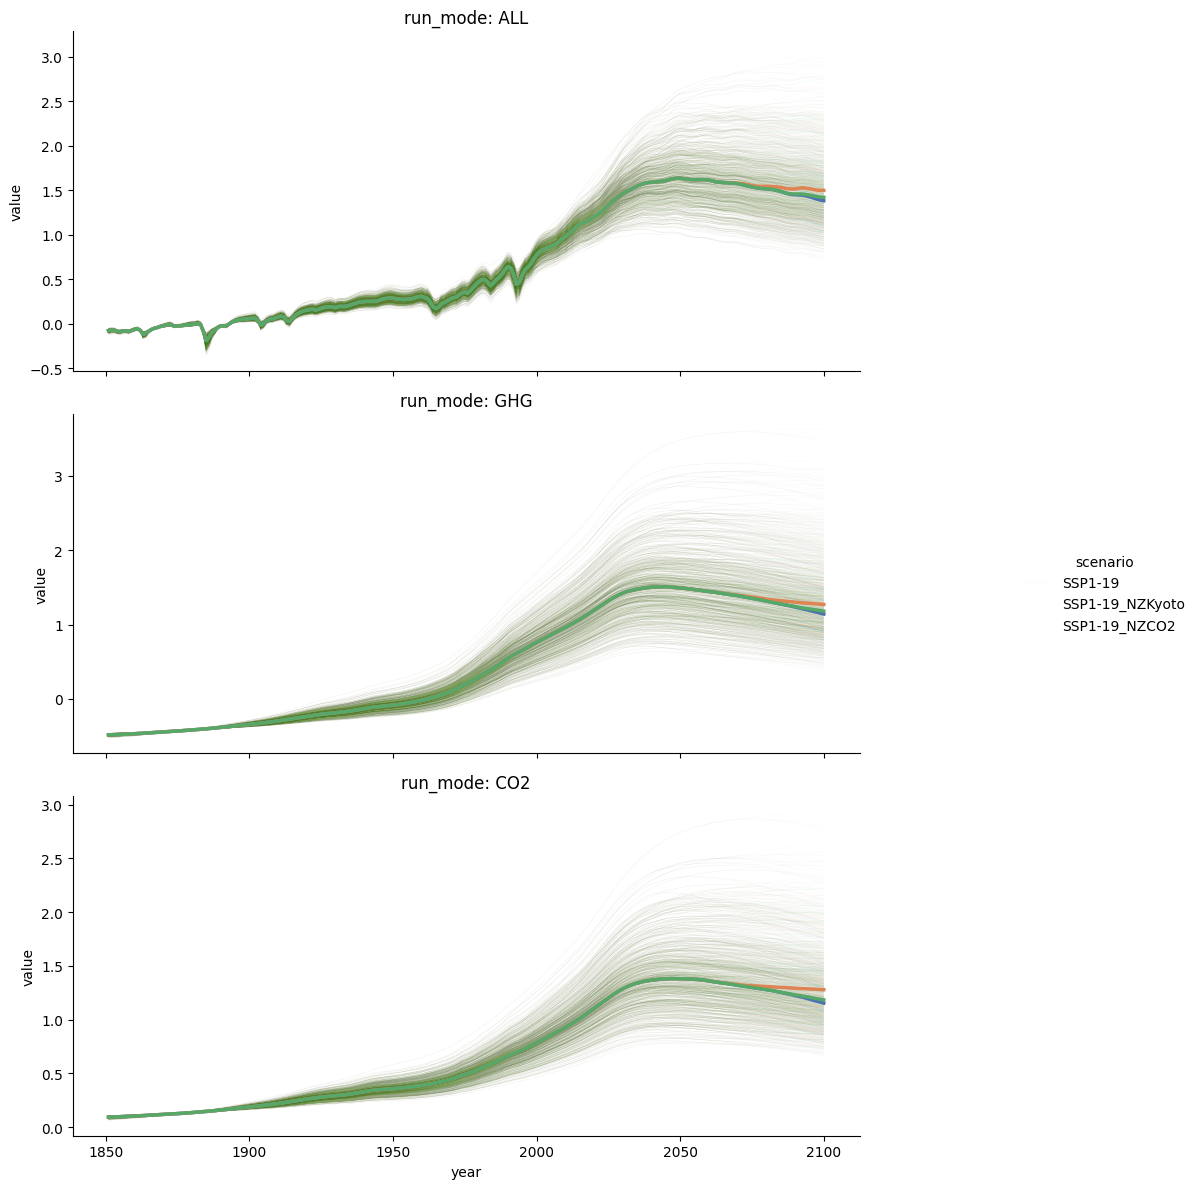

In [121]:
# --- ensure ordering ---
to_plot = to_plot.sort_values("year")

plt.figure(figsize=(8, 12))

# --- base plot: ensemble (faint gray lines) ---
g = sns.relplot(
    data=to_plot,
    x="year",
    y="value",
    kind="line",
    units="run_id",
    estimator=None,          # no aggregation
    hue="scenario",          # still useful for grouping structure
    col="run_mode",
    col_wrap=1,
    linewidth=0.2,
    alpha=0.05,
    color="gray",
    facet_kws={"sharey": False},
)

# --- compute medians ---
median_df = (
    to_plot
    .groupby(["year", "scenario", "run_mode"], as_index=False)["value"]
    .median()
)

# --- color palette for run_modes ---
run_modes = sorted(to_plot["run_mode"].unique())
palette = sns.color_palette("tab10", n_colors=len(run_modes))
run_mode_colors = dict(zip(run_modes, palette))

# --- overlay medians ---
for run_mode, ax in g.axes_dict.items():

    sub = median_df[median_df["run_mode"] == run_mode]

    sns.lineplot(
        data=sub,
        x="year",
        y="value",
        hue="scenario",
        ax=ax,
        linewidth=2.5,
        palette="deep",   # scenario colors for contrast
        legend=False,
    )

    ax.set_title(f"run_mode: {run_mode}")
    
# --- layout polish ---
g.fig.set_size_inches(12, 12)
g.tight_layout()